BASIC STATISTICS
# **Descriptive Analytics and Data Preprocessing on Sales & Discounts Dataset**


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
df = pd.read_csv('/content/sales_data_with_discounts.csv')

In [10]:
df.head()

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [11]:
df.shape

(450, 13)

In [12]:
#	Identify numerical columns in the dataset.
a = df.iloc[:,8:13]
a

,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,12100,181500,11.654820,21153.498820,160346.501180
1,10100,101000,11.560498,11676.102961,89323.897039
2,16100,112700,9.456886,10657.910157,102042.089843
3,20100,120600,6.935385,8364.074702,112235.925298
4,8100,24300,17.995663,4372.946230,19927.053770
...,...,...,...,...,...
445,1300,2600,15.475687,402.367873,2197.632127
446,2600,15600,17.057027,2660.896242,12939.103758
447,1600,3200,18.965550,606.897606,2593.102394
448,1900,5700,16.793014,957.201826,4742.798174


In [13]:
a.describe()

,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
count,450.000000,450.000000,450.000000,450.000000,450.000000
mean,10453.433333,33812.835556,15.155242,3346.499424,30466.336131
std,18079.904840,50535.074173,4.220602,4509.902963,46358.656624
min,290.000000,400.000000,5.007822,69.177942,326.974801
25%,465.000000,2700.000000,13.965063,460.459304,2202.208645
50%,1450.000000,5700.000000,16.577766,988.933733,4677.788059
75%,10100.000000,53200.000000,18.114718,5316.495427,47847.912852
max,60100.000000,196400.000000,19.992407,25738.022194,179507.479049


In [14]:
a['Avg Price'].mean()



np.float64(10453.433333333332)

In [15]:
a['Avg Price'].median()


1450.0

In [16]:

a['Avg Price'].mode()


,Avg Price
0,400
1,450
2,500
3,1300
4,8100


In [17]:

a['Avg Price'].std()

18079.90483993645

In [18]:
a['Total Sales Value'].mean()

np.float64(33812.83555555555)

In [19]:
a['Total Sales Value'].median()

5700.0

In [20]:
a['Total Sales Value'].mode()

,Total Sales Value
0,24300


In [21]:
a['Total Sales Value'].std()

50535.07417255328

In [22]:
a['Discount Rate (%)'].mean()

np.float64(15.155241895330914)

In [23]:
a['Discount Rate (%)'].median()

16.57776564929597

In [24]:
a['Discount Rate (%)'].mode()

,Discount Rate (%)
0,5.007822
1,5.055218
2,5.059801
3,5.072124
4,5.084108
...,...
445,19.940610
446,19.965340
447,19.976879
448,19.982257


In [25]:
a['Discount Rate (%)'].std()

4.220602153325511

In [26]:
a['Discount Amount'].mean()

np.float64(3346.499424342415)

In [27]:
a['Discount Amount'].median()

988.9337332382784

In [28]:
a['Discount Amount'].mode()

,Discount Amount
0,69.177942
1,73.025199
2,93.649161
3,94.682735
4,102.705757
...,...
445,17900.983733
446,21153.498820
447,21496.675367
448,25328.224204


In [29]:
a['Discount Amount'].std()

4509.9029633539985

In [30]:
a['Net Sales Value'].mean()

np.float64(30466.336131270138)

In [31]:
a['Net Sales Value'].median()

4677.788059301853

In [32]:
a['Net Sales Value'].mode()

,Net Sales Value
0,326.974801
1,330.822058
2,466.350839
3,485.317265
4,496.607104
...,...
445,162603.186379
446,163915.971000
447,163967.080070
448,166263.161348


In [33]:
a['Net Sales Value'].std()

46358.656624066934

In [34]:
#●	Histograms:
	#Plot histograms for each numerical column.
	#Analyze the distribution (e.g., skewness, presence of outliers) and provide inferences.


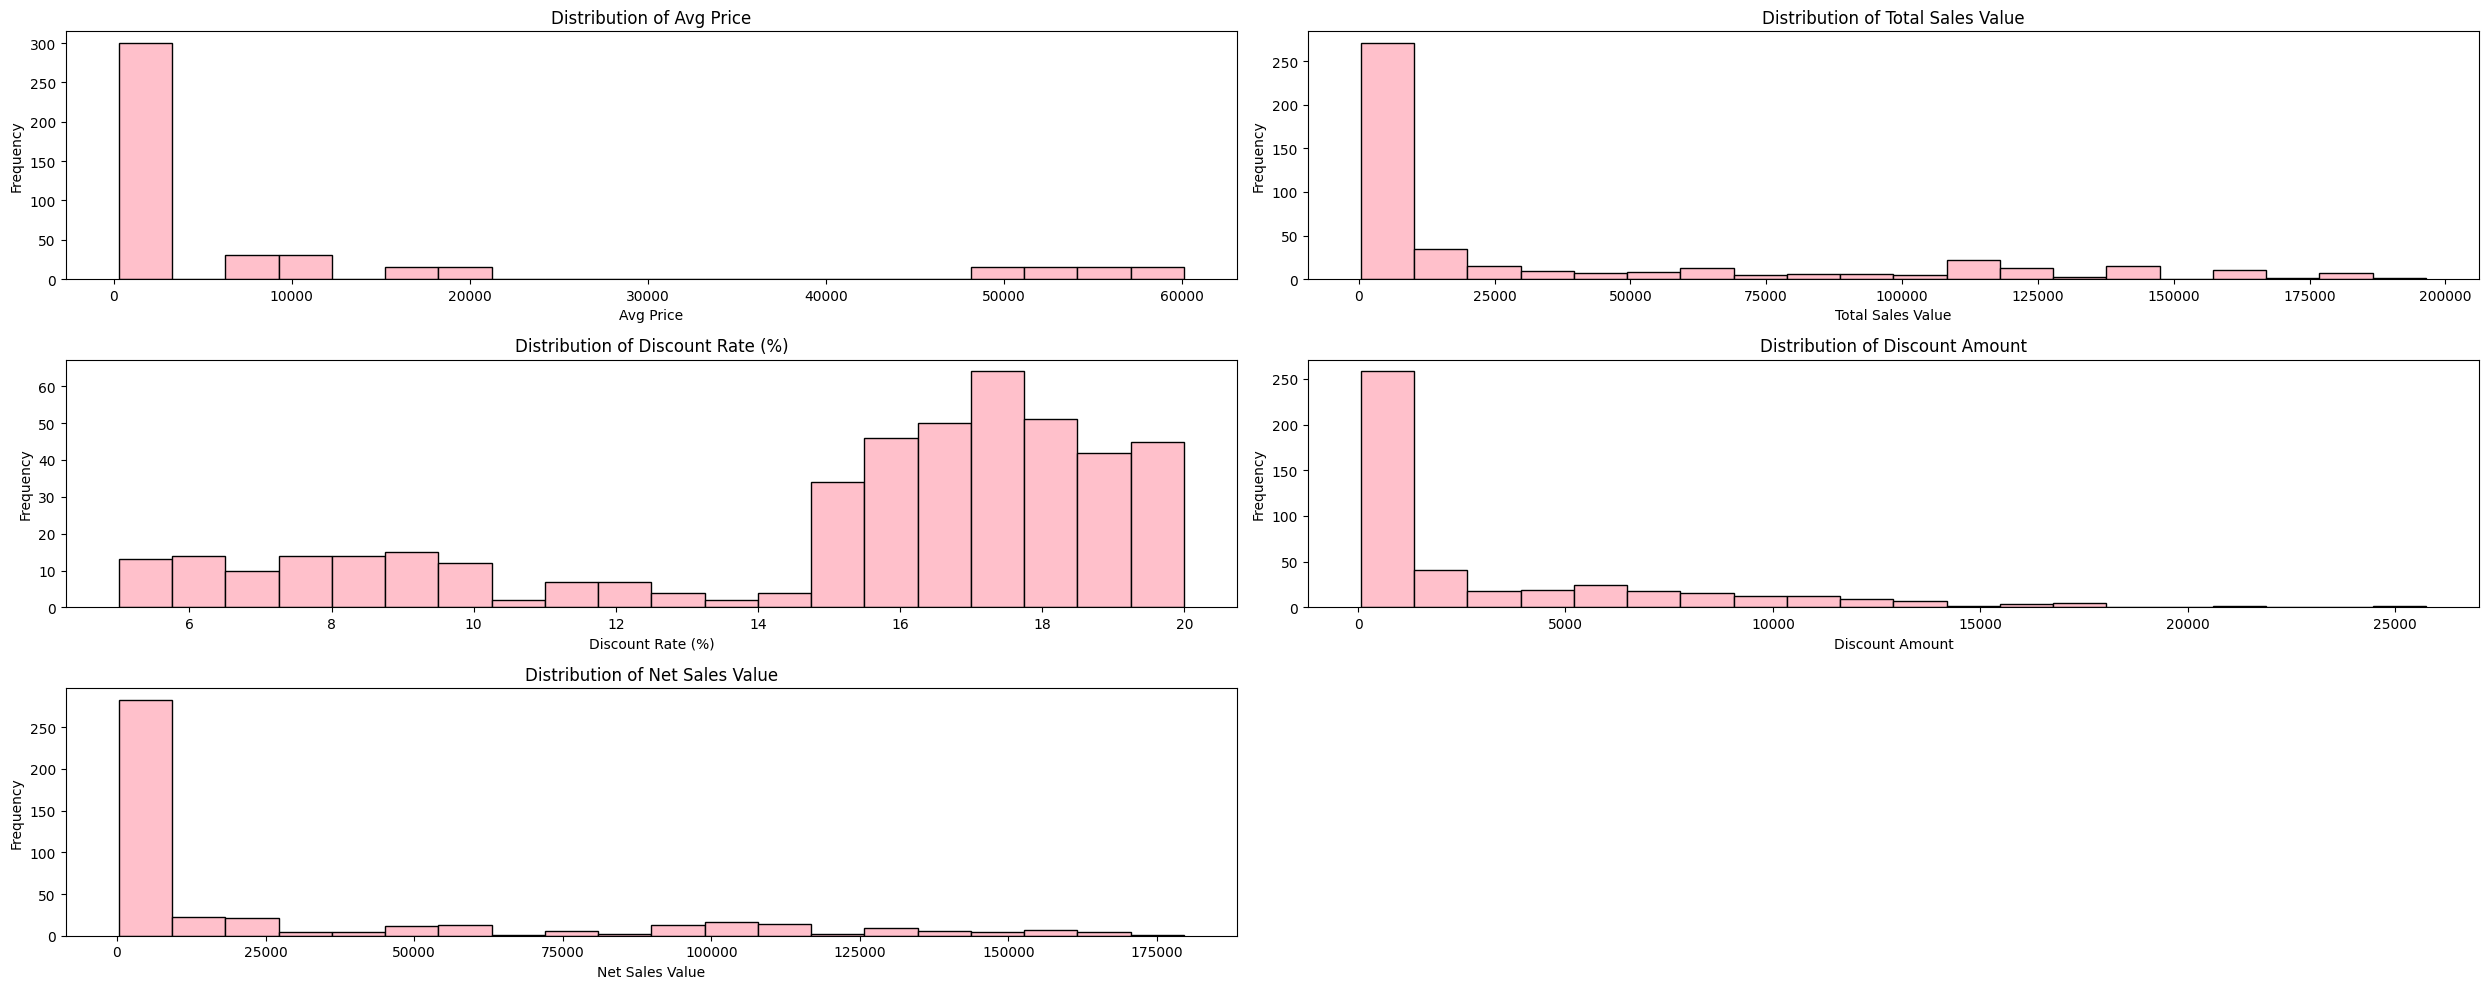

In [35]:
import matplotlib.pyplot as plt
plt.figure(figsize=(25, 10))


for i, column in enumerate(a.columns, 1):
    plt.subplot(3, 2, i)
    plt.hist(a[column], bins=20, color='pink', edgecolor='black')
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
# Avg Price, Total Sales Value, Discount Amount, and Net Sales Value all have a strong right-skewed distribution. The "long tail" going to  right represents a smaller number of high-value transactions, which shows outliers in the sales
#Discount Rate (%) shows a  symmetric and when we see it , its balanced. This shows that the sales fluctuate , the disocunts is given in a consist manner

In [36]:
#●	Box Plots:
	#Create boxplots for numerical variables to identify outliers and the interquartile range.
	#Discuss any findings, such as extreme values or unusual distributions


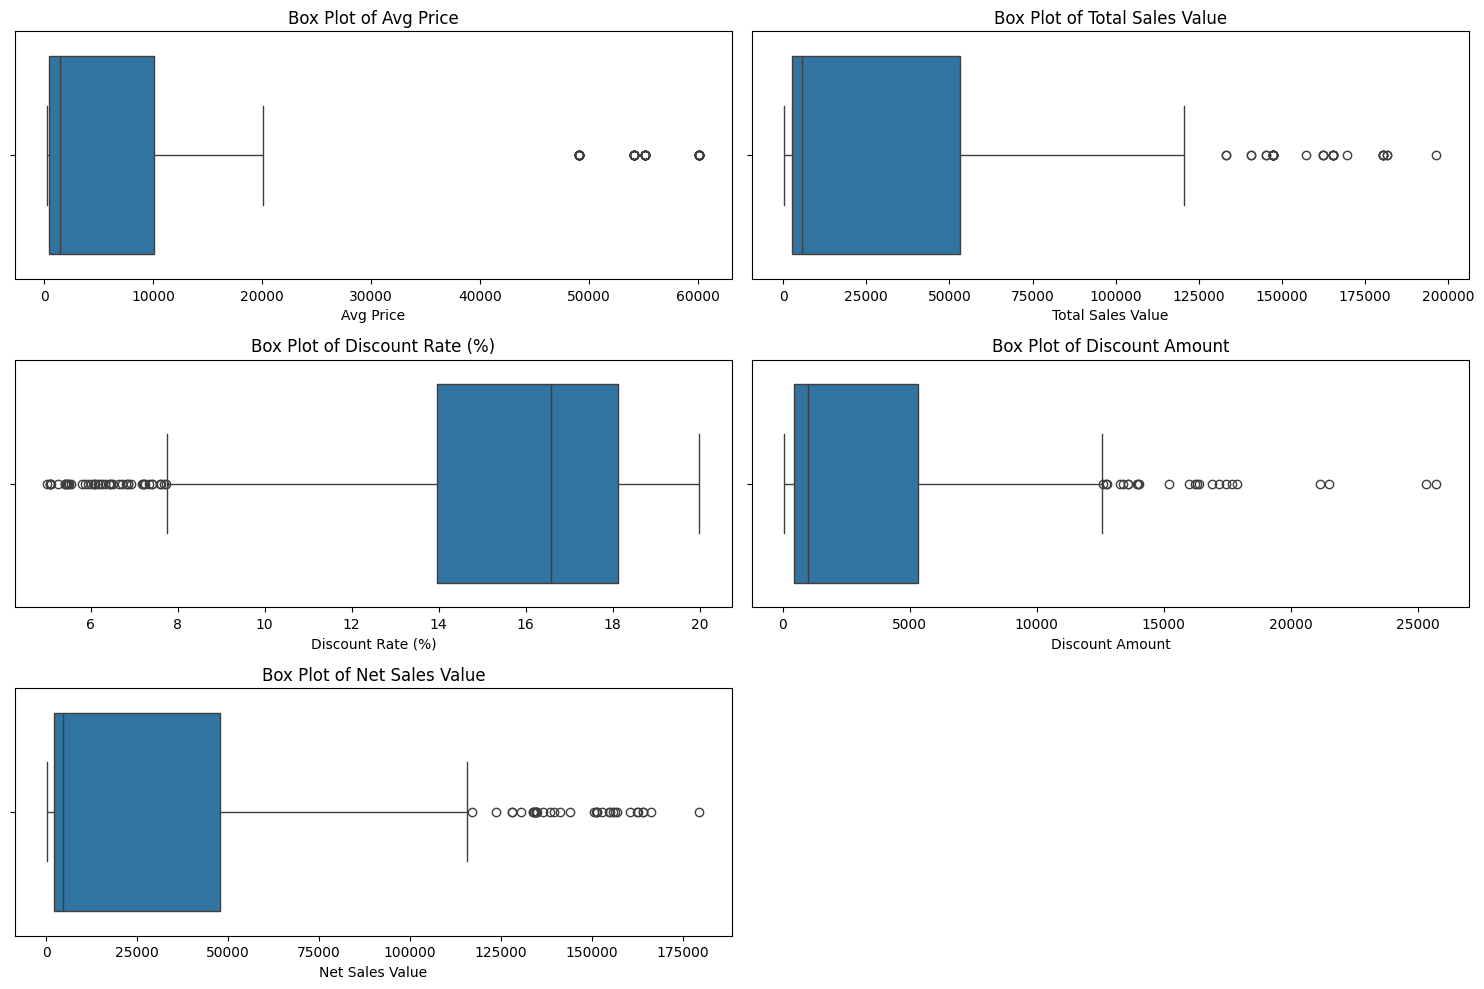

In [37]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 10))


for i, column in enumerate(a.columns, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(data=a ,x=column)
    plt.title(f'Box Plot of {column}')
    plt.xlabel(column)

plt.tight_layout()
plt.show()

In [ ]:
#This shows consistent pattern of right-skewed  across  Avg Price, Total Sales Value, and Net Sales Value alspo in discounted amount .After the plot we can determine that there are numerous outliers which is shown by single data point , revels that the dataset has extreme high values.

In [38]:
# Bar Chart Analysis for Categorical Column:
#	Identify categorical columns in the dataset.
#	Create bar charts to visualize the frequency or count of each category.
#	Analyze the distribution of categories and provide insights.


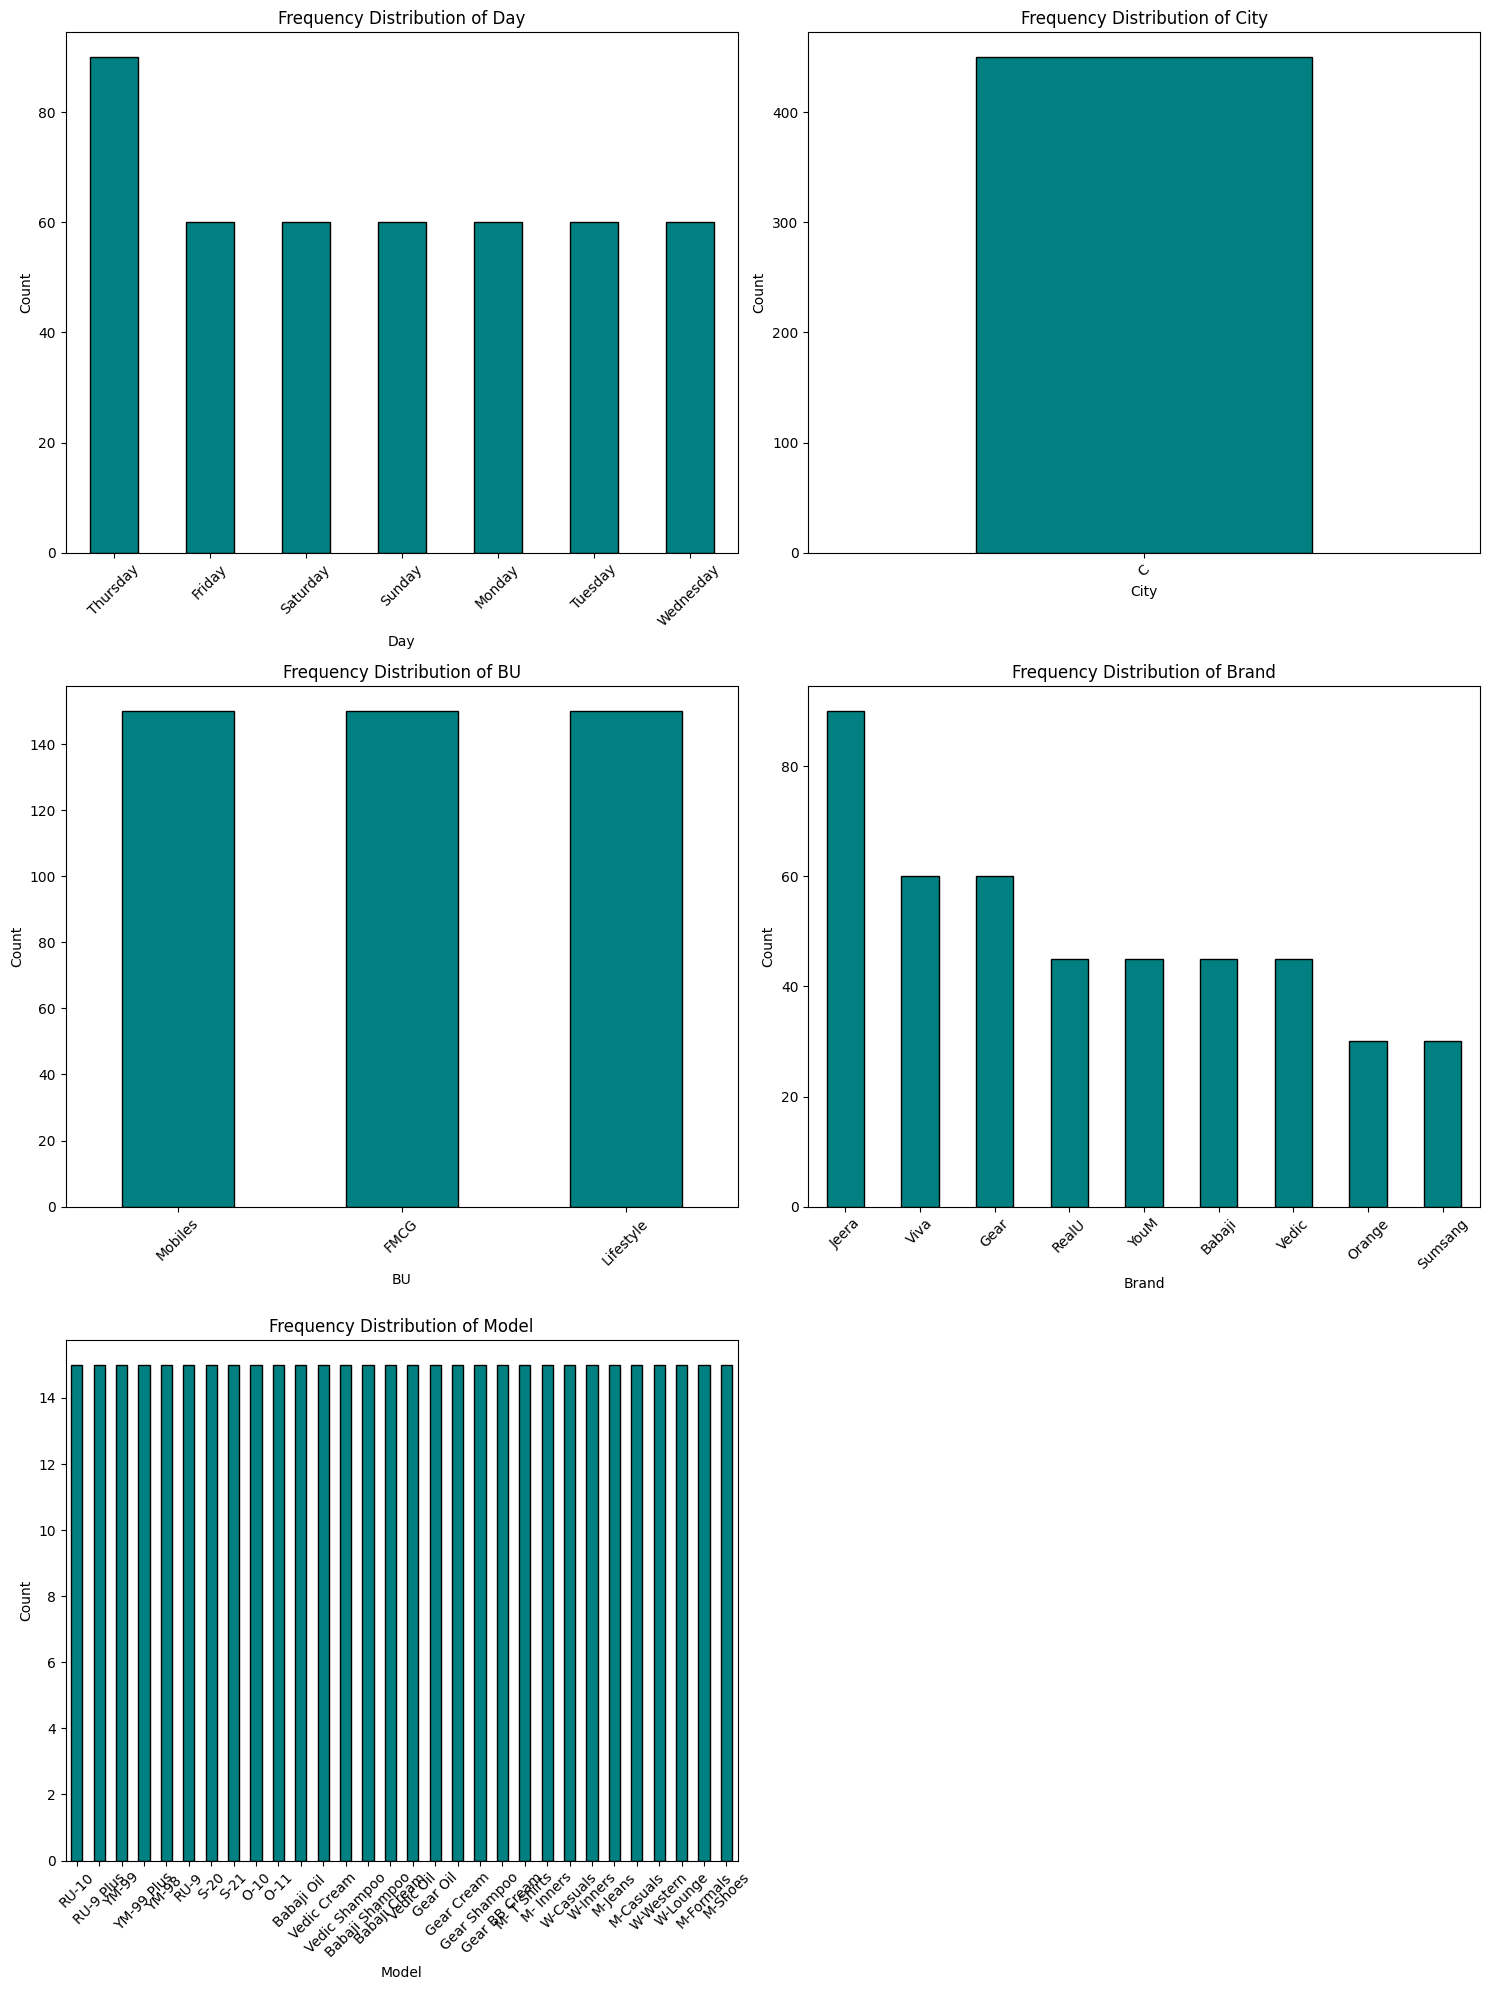

In [45]:
import matplotlib.pyplot as plt


cat_cols = ['Day', 'City', 'BU', 'Brand', 'Model']  #dates not included


plt.figure(figsize=(15, 20))

# Plotting each categorical column
for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 2, i)
    df[col].value_counts().plot(kind='bar', color='teal', edgecolor='black')
    plt.title(f'Frequency Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
#in  dataset, the categorical columns include Day, City, BU , Brand, and Model.
#When we look at Brand or City charts, we can notice that some bars are much taller than others. This tells you that the business sells way more of those specific brands or in those specific cities. They are "best-sellers"
#The bar charts show that yhe sales are not spread out evenly; instead, we have certain brands and locations that are much more popular than others, which act as the main items in the business